# Identifying YS and Allantois trajectory in vivo

In [1]:
here::i_am("revisions/01_invivo_lineages/01_manual_trajectory.ipynb")

source(here::here("settings.R"))
source(here::here("utils.R"))

suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(scater))
suppressPackageStartupMessages(library(Seurat))
suppressPackageStartupMessages(library(dplyr))
suppressPackageStartupMessages(library(edgeR))


BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 16

# Multi core using future - built in to seurat
plan("multicore", workers = 16)
options(future.globals.maxSize = 50 * 1024 ^ 3) # for 50 Gb RAM

set.seed(1234)

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/code

Warning message:
“package ‘rtracklayer’ was built under R version 4.2.3”


In [2]:
args = list()

# Metadata
args$metadata = '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation/pijuansala2019_gastrulation10x/sample_metadata_extended.txt.gz'

# RNA_sce
args$rna_sce = io$rna.atlas.sce

# outdir
args$outdir = file.path(io$basedir, 'results/revisions/01_invivo_lineages/')
dir.create(args$outdir, recursive=TRUE, showWarnings =FALSE)

In [3]:
meta = fread(args$metadata)

unique(meta$celltype)

[1] "Epiblast"                       "Primitive_Streak"              
 [3] "ExE_ectoderm"                   "Visceral_endoderm"             
 [5] "ExE_endoderm"                   "Nascent_mesoderm"              
 [7] "Rostral_neurectoderm"           "Blood_progenitors_2"           
 [9] "Mixed_mesoderm"                 "ExE_mesoderm"                  
[11] "Intermediate_mesoderm"          "Pharyngeal_mesoderm"           
[13] "Caudal_epiblast"                "PGC"                           
[15] "Mesenchyme"                     "Haematoendothelial_progenitors"
[17] "Blood_progenitors_1"            "Surface_ectoderm"              
[19] "Gut"                            "Paraxial_mesoderm"             
[21] "Caudal_neurectoderm"            "Notochord"                     
[23] "Somitic_mesoderm"               "Caudal_Mesoderm"               
[25] "Erythroid1"                     "Def._endoderm"                 
[27] "Parietal_endoderm"              "Allantois"                     
[29] "Anterior_Primitive_Streak"      "Endothelium"                   
[31] "Forebrain_Midbrain_Hindbrain"   "Spinal_cord"                   
[33] "Cardiomyocytes"                 "Erythroid2"                    
[35] "NMP"                            "Erythroid3"                    
[37] "Neural_crest"

In [4]:
rna.sce_full <- load_SingleCellExperiment(args$rna_sce, normalise = TRUE)

In [5]:
# Only run this code if not ran at the beginning:

# Get gene metadata
gene_metadata <- fread(io$gene_metadata) %>% .[,c("chr","ens_id","symbol")] %>%
  .[symbol!="" & ens_id %in% rownames(rna.sce_full)] %>%
  .[!duplicated(symbol)]

rna.sce_full = rna.sce_full[gene_metadata$ens_id,] # keep only genes with gene names

rownames(rna.sce_full) = gene_metadata[match(rownames(rna.sce_full), ens_id), symbol] # change rownames to gene names

In [6]:
# load meta
meta = fread(args$metadata)

celltypes = c(
              'Primitive_Streak',
              'Nascent_mesoderm',
              'Mixed_mesoderm',
              'Lateral_plate_mesoderm',
              'Allantois',
              'Haematoendothelial_progenitors', 
              'Blood_progenitors'
)

meta = meta[celltype_extended %in% celltypes]

In [7]:
# load sce
rna.sce <- rna.sce_full[,meta$cell]
colData(rna.sce) = meta %>% as.data.frame() %>% tibble::column_to_rownames('cell') %>% DataFrame()

In [8]:
source(here::here('rna/mapping/run/mnn/mapping_functions.R'))
library(batchelor)

# FastMNN batch correction

In [9]:
test = fastMNN(rna.sce, 
               batch = rna.sce$stage)

In [10]:
library(destiny)
DiffusionMap <- DiffusionMap(reducedDim(test,"corrected"))


Attaching package: ‘destiny’


The following object is masked from ‘package:SummarizedExperiment’:

    distance


The following object is masked from ‘package:GenomicRanges’:

    distance


The following object is masked from ‘package:IRanges’:

    distance


Warning message:
“as(<dsCMatrix>, "dsTMatrix") is deprecated since Matrix 1.5-0; do as(., "TsparseMatrix") instead”


In [11]:
test_bu = test

In [12]:
test <- runUMAP(test, dimred="corrected", n_neighbors = 35, min_dist = 0.15)

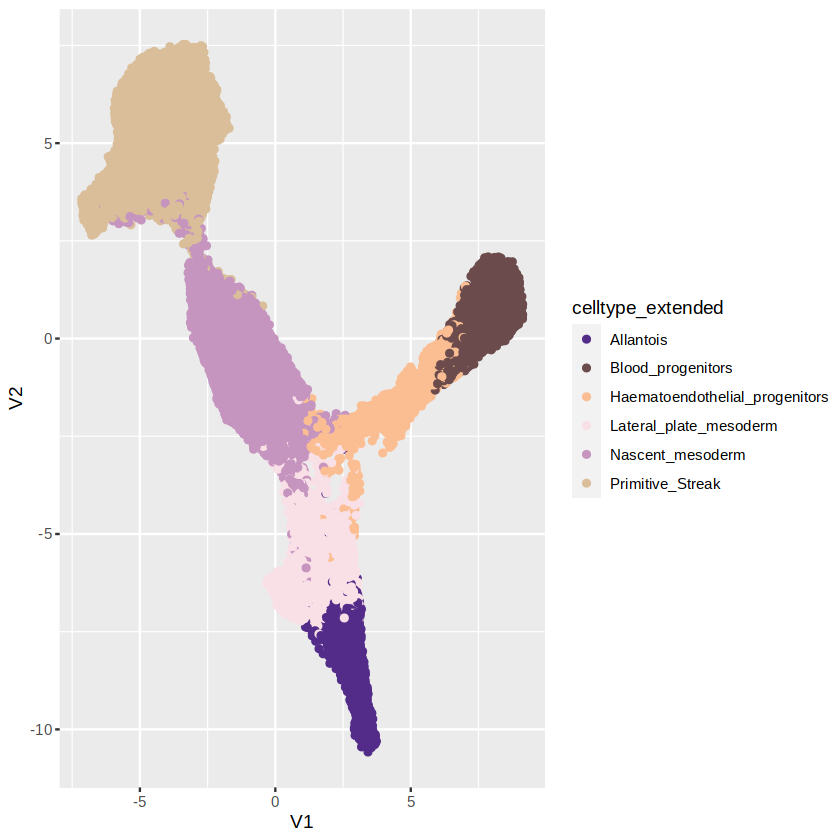

In [13]:
# Fetch UMAP coordinates
to.plot <- reducedDim(test,"UMAP") %>% as.data.table %>% 
    .[,cell:=colnames(test)] %>%
    merge(meta, by="cell")

ggplot(to.plot, aes(V1, V2, color = celltype_extended)) + 
    geom_point() + 
    scale_color_manual(values = opts$celltype_extended.colors)

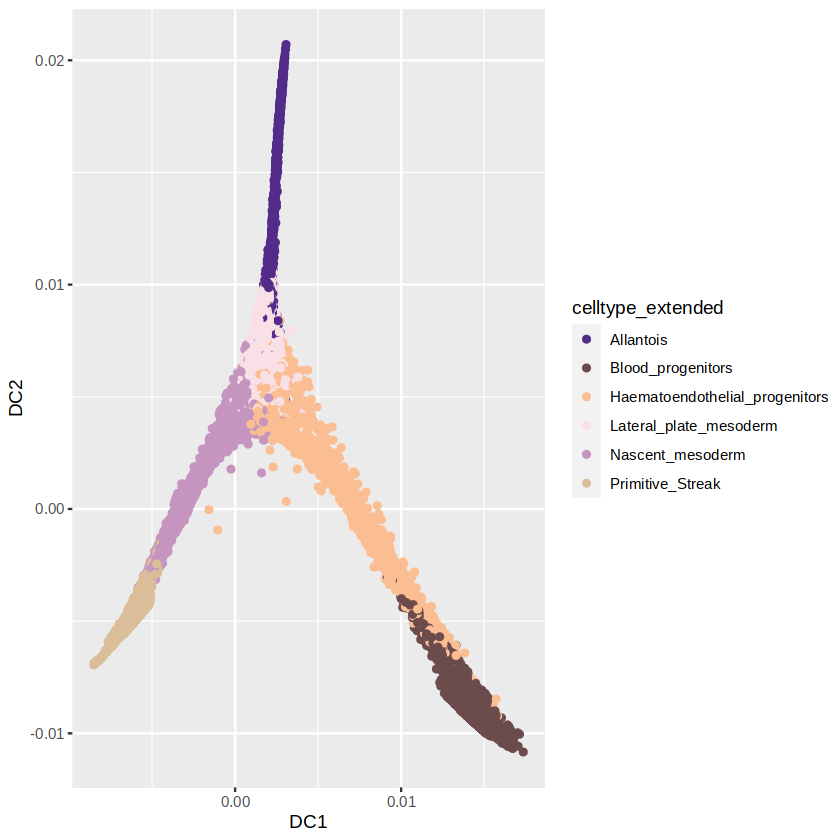

In [14]:
# Fetch UMAP coordinates
to.plot <- DiffusionMap@eigenvectors %>% as.data.table(., keep.rownames = T) %>% setnames('rn', 'cell') %>% 
    .[,cell:=colnames(test)] %>%
    merge(meta, by="cell")

ggplot(to.plot, aes(DC1, DC2, color = celltype_extended)) + 
    geom_point() + 
    scale_color_manual(values = opts$celltype_extended.colors)

In [15]:
library(slingshot)

Loading required package: princurve

Loading required package: TrajectoryUtils


Attaching package: ‘TrajectoryUtils’


The following object is masked from ‘package:scran’:

    createClusterMST




In [16]:
test = test_bu
colData(test) = colData(rna.sce)

In [17]:
set.seed(42)
# Somehow it crashes if using all PCs.
reducedDim(test, "corrected2") <- reducedDim(test, "corrected")[,1:5] # 1:5 works fine?

test <- slingshot(test, 
                     clusterLabels = 'celltype_extended', 
                     start.clus = 'Primitive_Streak', 
                     omega = T, # play around until trajectories look good
                     shrink = T,
                     reducedDim='corrected2')

In [18]:
reducedDim(test, "diffusion") <- DiffusionMap@eigenvectors[,c(1:2)]

In [26]:
saveRDS(test, file.path(args$outdir, 'slingshot.rds'))

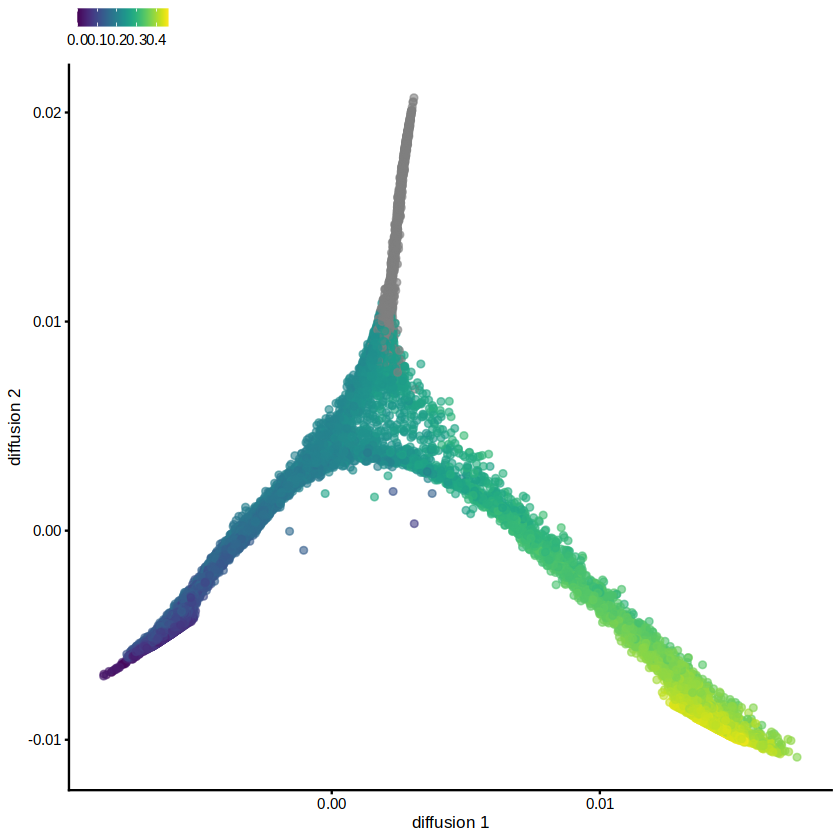

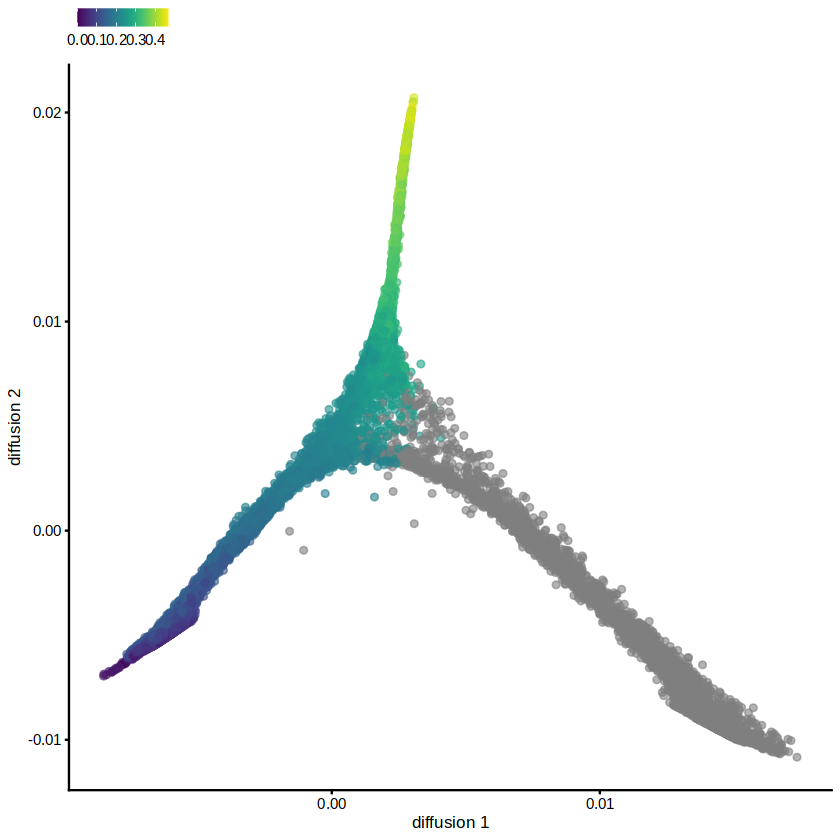

In [19]:
colData(test)$pseudotime = colData(test)$slingPseudotime_1 # meta %>% tibble::column_to_rownames("cell") %>% DataFrame
plotReducedDim(test, dimred = "diffusion", colour_by="pseudotime", ncomponents = c(1,2)) +
    theme(legend.position="top", legend.title = element_blank())

colData(test)$pseudotime = colData(test)$slingPseudotime_2 # meta %>% tibble::column_to_rownames("cell") %>% DataFrame
plotReducedDim(test, dimred = "diffusion", colour_by="pseudotime", ncomponents = c(1,2)) +
    theme(legend.position="top", legend.title = element_blank())

In [30]:
# Assign cells to lineages
set.seed(1234)
assign_lineages = tradeSeq:::.assignCells(assays(test$slingshot)$weights)
#colnames(assign_lineages) = c('Trajectory1', 'Trajectory2')
pseudotime = slingPseudotime(test$slingshot, na=T)

Traj_assignment = as.data.table(assign_lineages, keep.rownames=T) %>%
    setnames(c('cell', paste0('Trajectory', 1:(length(.)-1))))

In [31]:
meta2 = merge(meta, Traj_assignment)
meta2 = cbind(meta2, as.data.table(DiffusionMap@eigenvectors[meta2$cell,c(1:2)]))

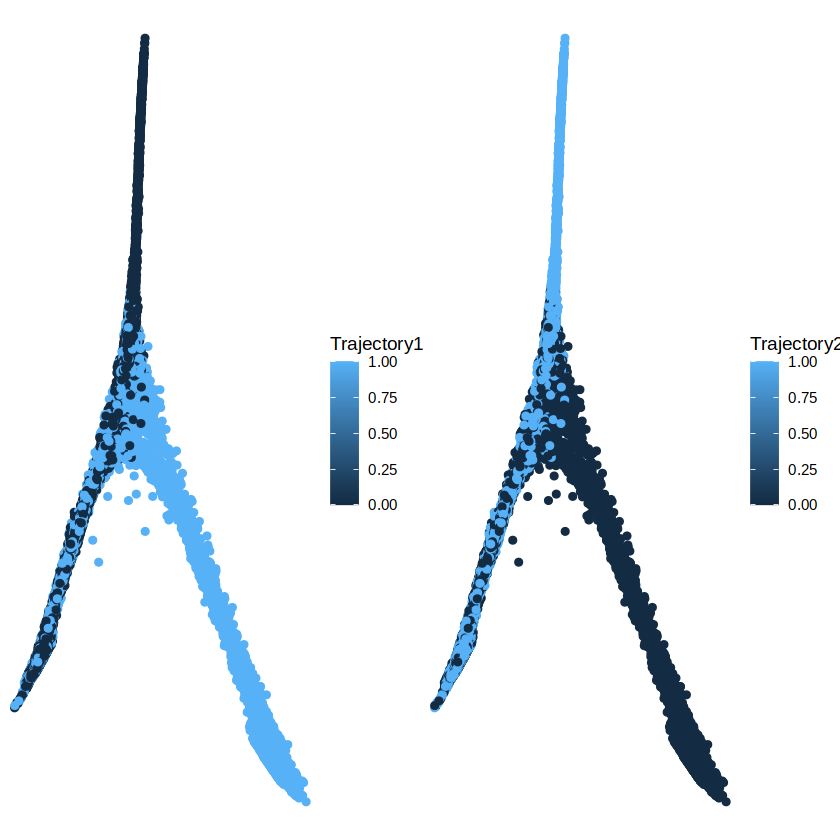

In [32]:
p1 = ggplot(meta2, aes(DC1, DC2, col = Trajectory1)) + 
    geom_point() + 
    theme_void()

p2 = ggplot(meta2, aes(DC1, DC2, col = Trajectory2)) + 
    geom_point() + 
    theme_void()

ggarrange(p1, p2)

In [33]:
# Keep only cells within pseudotime window for analysis
tmp = Traj_assignment
tmp2 = as.data.table(pseudotime, keep.rownames=T)
pseudo_min = 0
pseudo_max = 23

lineage1_keep = tmp2[rn %in% tmp[Trajectory1==1, cell]] %>% .[Lineage1 >= pseudo_min & Lineage1 <= pseudo_max] %>% .$rn
lineage2_keep = tmp2[rn %in% tmp[Trajectory2==1, cell]] %>% .[Lineage2 >= pseudo_min & Lineage2 <= pseudo_max] %>% .$rn

within_pseudotime_cells = c(lineage1_keep, lineage2_keep)

In [34]:
library(tradeSeq)

In [35]:
rna.sce <- rna.sce_full[,meta$cell]
colData(rna.sce) = meta %>% as.data.frame() %>% tibble::column_to_rownames('cell') %>% DataFrame()

decomp <- modelGeneVar(rna.sce[,within_pseudotime_cells])
decomp <- decomp[decomp$mean > 0.001, ]
decomp$FDR <- p.adjust(decomp$p.value, method = "fdr")
genes = as.data.table(decomp, keep.rownames = T) %>%
    .[order(FDR)] %>% head(10000) %>% .$rn

length(genes)

Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”


[1] 10000

In [36]:
BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 4

#U <- model.matrix(~as.factor(rna.sce$sample))
sceGAM <- fitGAM(counts = counts(rna.sce)[,within_pseudotime_cells], 
                 pseudotime = slingPseudotime(test$slingshot, na=F)[within_pseudotime_cells,],
                 cellWeights = assign_lineages[within_pseudotime_cells,],                 
                 #U = U, # Don't use replicates for test
                 nknots=8, 
                 genes = genes, # Only look at top 10k genes --> should probably reduce this further since it's already a ton, would improve FDR 
                 parallel = T,
                 BPPARAM=BPPARAM,
                 verbose=T)

Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 5.0 GiB”


  |======================================================================| 100%



In [37]:
saveRDS(sceGAM, file.path(args$outdir, 'sceGAM_v2.rds'))

In [ ]:
sceGAM = readRDS(file.path(args$outdir, 'sceGAM_v2.rds'))

In [ ]:
sceGAM

In [ ]:
library(tradeSeq)

In [ ]:
patternRes <- patternTest(sceGAM, l2fc=1) # Perform pattern testing with set l2fc
patternGenes = patternRes %>% as.data.table(keep.rownames=T) %>%
    setnames('rn', 'gene') %>% # rename gene column
    .[waldStat != 0] %>% # Before multiple testing comparison, remove genes that do not qualify according to l2fc
    .[,padj:= p.adjust(pvalue, "fdr")] %>% # Multiple testing comparison
    .[,sig:=ifelse(padj<=0.05, TRUE, FALSE)] # Set significance
nrow(patternGenes[sig==TRUE])

In [ ]:
endRes <- diffEndTest(sceGAM, l2fc=1) # Perform pattern testing with set l2fc
endGenes = endRes %>% as.data.table(keep.rownames=T) %>%
    setnames('rn', 'gene') %>% # rename gene column
    .[waldStat != 0] %>% # Before multiple testing comparison, remove genes that do not qualify according to l2fc
    .[,padj:= p.adjust(pvalue, "fdr")] %>% # Multiple testing comparison
    .[,sig:=ifelse(padj<=0.05, TRUE, FALSE)] # Set significance
nrow(endGenes[sig==TRUE])

In [ ]:
fwrite(patternGenes, file.path(args$outdir, 'patternGenes_v2.txt.gz'))
fwrite(endGenes, file.path(args$outdir, 'endGenes_v2.txt.gz'))

In [ ]:
patternGenes = fread(file.path(args$outdir, 'patternGenes_v2.txt.gz'))
endGenes = fread(file.path(args$outdir, 'endGenes_v2.txt.gz'))

In [ ]:
genes_keep = unique(rbind(patternGenes[,c('gene', 'waldStat', 'padj', 'sig')], endGenes[,c('gene', 'waldStat', 'padj', 'sig')])[sig==TRUE][order(padj, -waldStat)]$gene)

In [ ]:
length(genes_keep)

In [ ]:
head(patternGenes[order(padj)])

In [ ]:
suppressPackageStartupMessages(library(circlize))
suppressPackageStartupMessages(library(scales))
suppressPackageStartupMessages(library(ComplexHeatmap))

# Get smoothed expession
yhatSmooth <- predictSmooth(sceGAM, gene = genes_keep, nPoints = 100, tidy = FALSE)

# minmax normalisation 
minmax = function(x){(x-min(x))/(max(x)-min(x))}
yhatSmooth_minmax = t(apply(yhatSmooth, 1, minmax)) 

# Separate YS and Allantois trajectories
YS = yhatSmooth_minmax[, grepl('lineage1', colnames(yhatSmooth_minmax))] # again trajectory names are switched
Alnt = yhatSmooth_minmax[, grepl('lineage2', colnames(yhatSmooth_minmax))]

In [ ]:
set.seed(42)
k = 10
group = kmeans(yhatSmooth_minmax, centers = k)$cluster

row_clust = cluster_within_group(t(yhatSmooth_minmax), group)

In [ ]:
# Specify which rows to annotate
rows_to_annotate <- c('Eomes', 'Lhx1', 'Nfatc1', 'Etv2', 'Sox7', 'Tal1',
          'Snai2', 'Hand1', 'Hoxa10',  'Smad3','Sox6', 'Tbx4'
                     )
row_indices <- which(rownames(YS) %in% rows_to_annotate)
row_anno = rowAnnotation(link = anno_mark(at = row_indices, 
        labels = rownames(YS)[row_indices], 
        labels_gp = gpar(fontsize = 10), padding = unit(1, "mm")))

In [ ]:
# Clustering
hm_list = Heatmap(Alnt, 
           row_gap = unit(0.5, "mm"),
            cluster_columns = FALSE,
            column_title = 'Trajectory 1',
            show_column_names  = FALSE,
            show_row_names  = FALSE,
          # col = cols,
            show_heatmap_legend = FALSE,
            row_split = group, 
           # left_annotation = ha_row,
            show_row_dend = FALSE,
            row_order = order(group, decreasing = TRUE),
            # heatmap_legend_param = list(title = 'Expression'), 
            row_title_gp = gpar(fontsize = 7),
            column_title_gp = gpar(fontsize = 7),
           # top_annotation = ha_alnt,
            border = TRUE,
            border_gp = gpar(col = "black", lwd = 0.5),
            use_raster = TRUE,
            raster_device = "png",
            raster_quality = 1) + 
          Heatmap(YS, 
           row_gap = unit(0.5, "mm"),
            cluster_columns = FALSE,
            column_title = 'Trajectory 2',
            show_column_names  = FALSE,
            show_row_names  = FALSE,
          #  col = cols,
            show_heatmap_legend = FALSE,
            row_split = group, 
            left_annotation = NULL,
            show_row_dend = FALSE,
            row_order = order(group, decreasing = TRUE),
            column_title_gp = gpar(fontsize = 7),
          #  top_annotation = ha_ys,
            border = TRUE,
            border_gp = gpar(col = "black", lwd = 0.5),
            use_raster = TRUE,
            raster_device = "png",
            raster_quality = 1
                 )

options(repr.plot.height=5, repr.plot.width=8)
plot = draw(hm_list + row_anno)

plot

In [ ]:
genes = c('Eomes', 'Lhx1', 'Nfatc1', 'Etv2', 'Sox7', 'Tal1',
          'Snai2', 'Hand1', 'Hoxa10', 'Sox6', 'Tbx4'
         )

genes = genes[genes %in% rownames(sceGAM)]
yhatSmooth <- predictSmooth(sceGAM, gene = genes, nPoints = 100, tidy=TRUE)

    RNA_filt.dt = as.data.table(yhatSmooth[yhatSmooth$gene %in% genes,]) %>% 
            setnames(c('lineage', 'time', 'yhat'), c('Traj', 'pseudotime', 'Expr')) %>%
            .[,gene:=factor(gene, levels = genes)] %>%
            .[,Traj:=as.character(Traj)]

    p = ggplot(RNA_filt.dt, aes(pseudotime, Expr, color=Traj)) + 
        #    geom_point(size=0.2, alpha=0.2) +
            geom_line(linewidth = 1.3) + 
            scale_color_manual(values=c('1'='chartreuse4', '2'='darkorchid4'), name='Trajectory') + 
            scale_x_continuous(expand=c(0.01,0, 0, 0), breaks=c(seq(2, 50, 3))) + 
            scale_y_continuous(expand=c(0,0, 0.1, 0), breaks=seq(0, 1e3, 3)) + 
        #    geom_smooth(se = F) +
            geom_hline(yintercept=0) +
            facet_wrap(~gene, ncol=12, scales='free_y') + 
            theme_bw() + 
            theme(strip.background = element_blank(),
                  text = element_text(size=20),
                  axis.text = element_text(color='black'),
                  axis.text.x = element_text(angle=-45, hjust=0, vjust=1),
                  axis.text.y = element_blank())

In [ ]:
options(repr.plot.height=4, repr.plot.width=30)
p

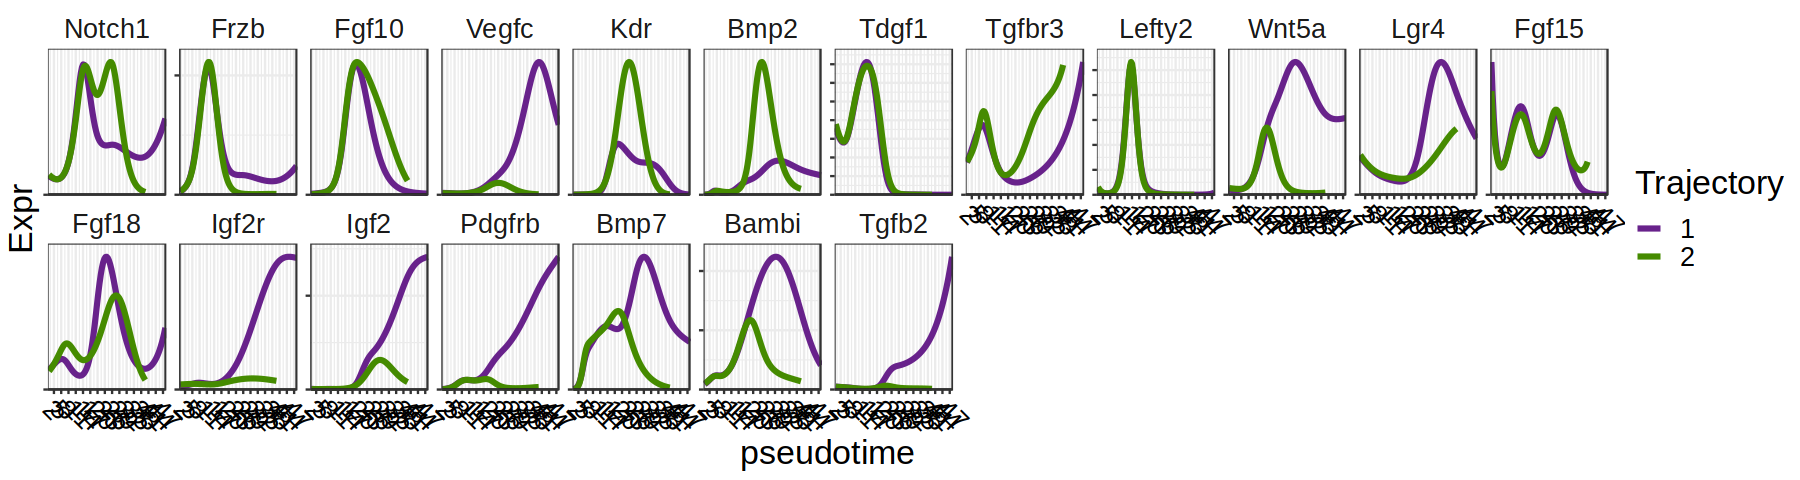

In [76]:
genes = c(
'Notch1','Fzd7',  'Frzb', 'Fgf10','Vegfc', 'Kdr','Bmp2','Tdgf1', 'Tgfbr3','Lefty2',
'Notch3', 'Wnt5a','Lgr4', 'Fgf15', 'Fgf18', 'Igf2r', 'Igf2', 'Pdgfrb', 'Bmp7', 'Bambi', 'Tgfb2', 'Smad9')
genes = genes[genes %in% rownames(sceGAM)]
yhatSmooth <- predictSmooth(sceGAM, gene = genes, nPoints = 100, tidy=TRUE)

    RNA_filt.dt = as.data.table(yhatSmooth[yhatSmooth$gene %in% genes,]) %>% 
            setnames(c('lineage', 'time', 'yhat'), c('Traj', 'pseudotime', 'Expr')) %>%
            .[,gene:=factor(gene, levels = genes)] %>%
            .[,Traj:=as.character(Traj)]

    p = ggplot(RNA_filt.dt, aes(pseudotime, Expr, color=Traj)) + 
        #    geom_point(size=0.2, alpha=0.2) +
            geom_line(linewidth = 1.3) + 
            scale_color_manual(values=c('2'='chartreuse4', '1'='darkorchid4'), name='Trajectory') + 
            scale_x_continuous(expand=c(0.01,0, 0, 0), breaks=c(seq(2, 50, 3))) + 
            scale_y_continuous(expand=c(0,0, 0.1, 0), breaks=seq(0, 1e3, 3)) + 
        #    geom_smooth(se = F) +
            geom_hline(yintercept=0) +
            facet_wrap(~gene, ncol=12, scales='free_y') + 
            theme_bw() + 
            theme(strip.background = element_blank(),
                  text = element_text(size=20),
                  axis.text = element_text(color='black'),
                  axis.text.x = element_text(angle=-45, hjust=0, vjust=1),
                  axis.text.y = element_blank())

options(repr.plot.height=4, repr.plot.width=15)
p

In [150]:
rownames(sceGAM)

[1] "Lefty2"  "Hand1"   "Pmp22"   "Meg3"    "Lgals1"  "Krt8"    "Krt18"  
 [8] "Pou5f1"  "Malat1"  "Fth1"    "Lmo2"    "Dnmt3b"  "Ube2c"   "Car2"   
[15] "Prdx1"   "Cited4"  "Id3"     "Mest"    "Tmsb10"  "Mesp1"   "Hbb-bh1"
[22] "Ifitm1"  "Cdkn1c"  "Phlda2"  "Hspa8"   "Tdgf1"   "mt-Nd1"  "mt-Atp6"
[29] "Rpl10"   "Xist"    "Bex4"    "Bex1"    "Wbp5"    "Spin2c"  "Tuba1a" 
[36] "Cited2"  "Trh"     "Emb"     "mt-Cytb" "Car4"    "Actg1"   "mt-Co3" 
[43] "Id1"     "Bex3"    "Etv2"    "Eef1a1"  "Ccnd2"   "Myl7"    "Cd24a"  
[50] "Fgf8"

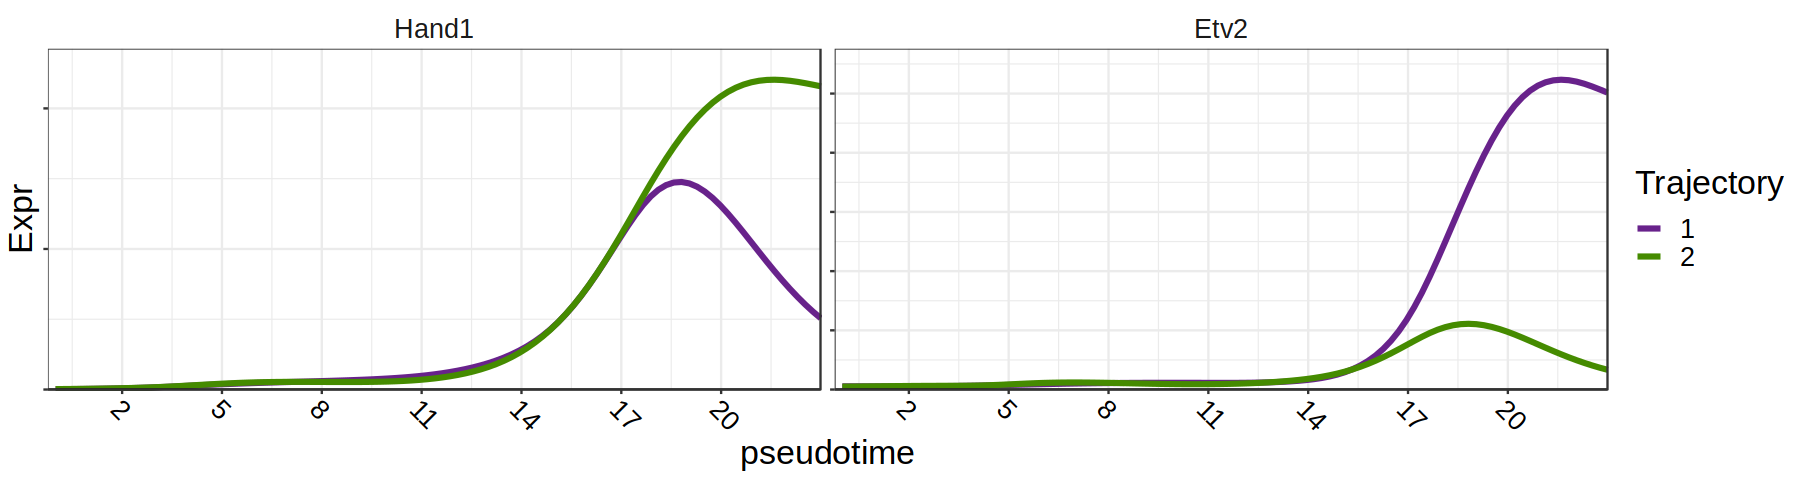

In [160]:
genes = c('Hand1', 'Etv2')
genes = genes[genes %in% rownames(sceGAM)]
yhatSmooth <- predictSmooth(sceGAM, gene = genes, nPoints = 100, tidy=TRUE)

    RNA_filt.dt = as.data.table(yhatSmooth[yhatSmooth$gene %in% genes,]) %>% 
            setnames(c('lineage', 'time', 'yhat'), c('Traj', 'pseudotime', 'Expr')) %>%
            .[,gene:=factor(gene, levels = genes)] %>%
            .[,Traj:=as.character(Traj)]

    p = ggplot(RNA_filt.dt, aes(pseudotime, Expr, color=Traj)) + 
        #    geom_point(size=0.2, alpha=0.2) +
            geom_line(linewidth = 1.3) + 
            scale_color_manual(values=c('2'='chartreuse4', '1'='darkorchid4'), name='Trajectory') + 
            scale_x_continuous(expand=c(0.01,0, 0, 0), breaks=c(seq(2, 50, 3))) + 
            scale_y_continuous(expand=c(0,0, 0.1, 0), breaks=seq(0, 1e3, 3)) + 
        #    geom_smooth(se = F) +
            geom_hline(yintercept=0) +
            facet_wrap(~gene, ncol=12, scales='free_y') + 
            theme_bw() + 
            theme(strip.background = element_blank(),
                  text = element_text(size=20),
                  axis.text = element_text(color='black'),
                  axis.text.x = element_text(angle=-45, hjust=0, vjust=1),
                  axis.text.y = element_blank())

options(repr.plot.height=4, repr.plot.width=15)
p

In [ ]:
decomp <- modelGeneVar(rna.sce, block = rna.sce$stage)
decomp <- decomp[decomp$mean > 0.001, ]
decomp$FDR <- p.adjust(decomp$p.value, method = "fdr")
genes = as.data.table(decomp, keep.rownames = T) %>%
    .[order(FDR)] %>% head(5000) %>% .$rn

length(genes)

In [ ]:
# Dimensionality reduction
pca <- multiBatchPCA(
    rna.sce,
    batch = rna.sce$stage,
    subset.row = genes,
    d = 10,
    preserve.single = TRUE,
    assay.type = "logcounts"
)[[1]]

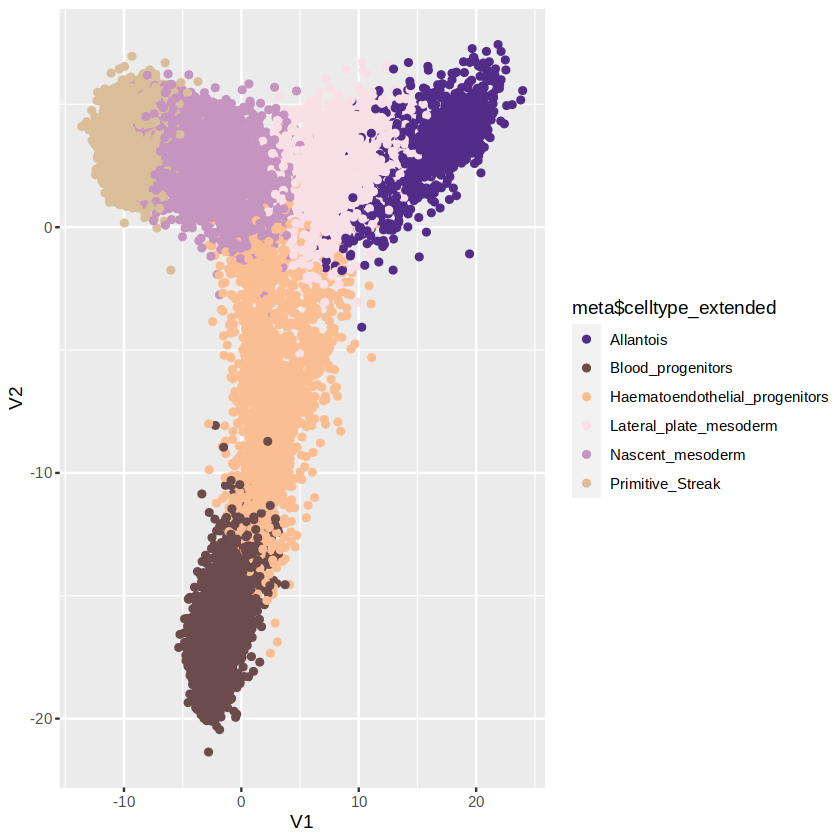

In [42]:
ggplot(as.data.table(pca), aes(V1, V2, color = meta$celltype_extended)) + 
    geom_point() + 
    scale_color_manual(values = opts$celltype_extended.colors)

In [43]:
# Batch effect correction for the atlas
message("Batch effect correction for the atlas...")  
order_df        <- meta[!duplicated(meta$sample), c("stage", "sample")]
order_df$ncells <- sapply(order_df$sample, function(x) sum(meta$sample == x))
order_df$stage  <- factor(order_df$stage, 
                        levels = rev(c("E8.5",
                                       "E8.25",
                                       "E8.0",
                                       "E7.75",
                                       "E7.5",
                                       "E7.25",
                                       "mixed_gastrulation",
                                       "E7.0",
                                       "E6.75",
                                       "E6.5")))
order_df       <- order_df[order(order_df$stage, order_df$ncells, decreasing = TRUE),]
order_df$stage <- as.character(order_df$stage)

set.seed(42)
pca_atlas_corrected <- doBatchCorrect(counts         = logcounts(rna.sce[genes,]), 
                                timepoints      = meta$stage, 
                                samples         = meta$sample, 
                                timepoint_order = order_df$stage, 
                                sample_order    = order_df$sample, 
                                pc_override     = pca,
                                npc             = 50)

Batch effect correction for the atlas...



In [44]:
reducedDim(rna.sce, "PCA") <- pca
reducedDim(rna.sce, "PCA_corrected") <- pca_atlas_corrected

In [45]:
rna.sce <- runUMAP(rna.sce, dimred="PCA", n_neighbors = 35, min_dist = 0.3)

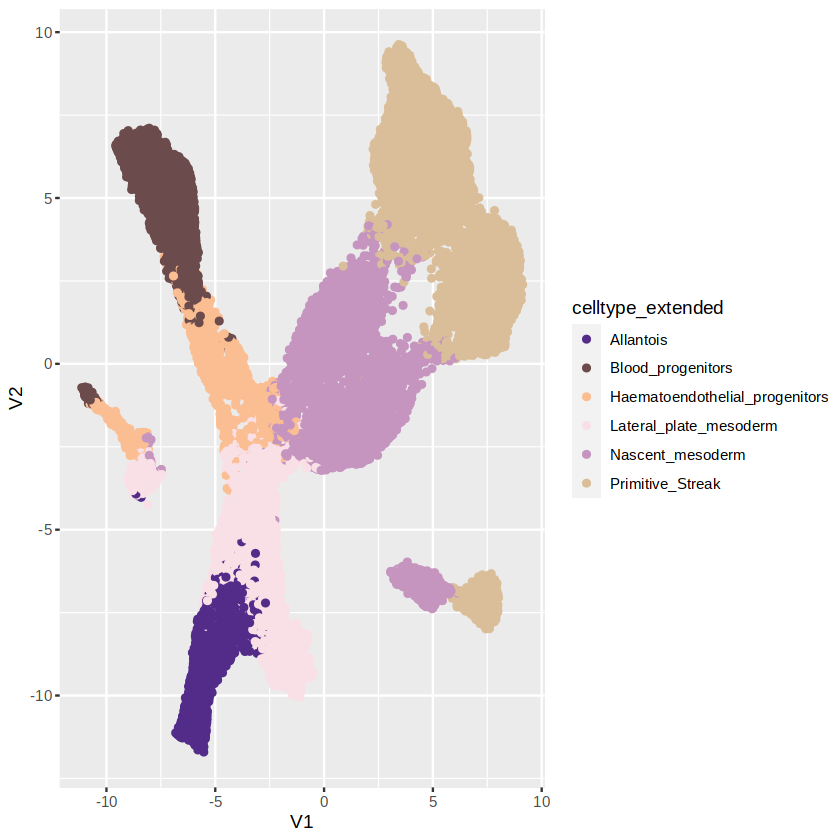

In [46]:
# Fetch UMAP coordinates
to.plot <- reducedDim(rna.sce,"UMAP") %>% as.data.table %>% 
    .[,cell:=colnames(rna.sce)] %>%
    merge(meta, by="cell")

ggplot(to.plot, aes(V1, V2, color = celltype_extended)) + 
    geom_point() + 
    scale_color_manual(values = opts$celltype_extended.colors)

In [47]:
rna.sce <- runUMAP(rna.sce, dimred="PCA_corrected", n_neighbors = 35, min_dist = 0.15)

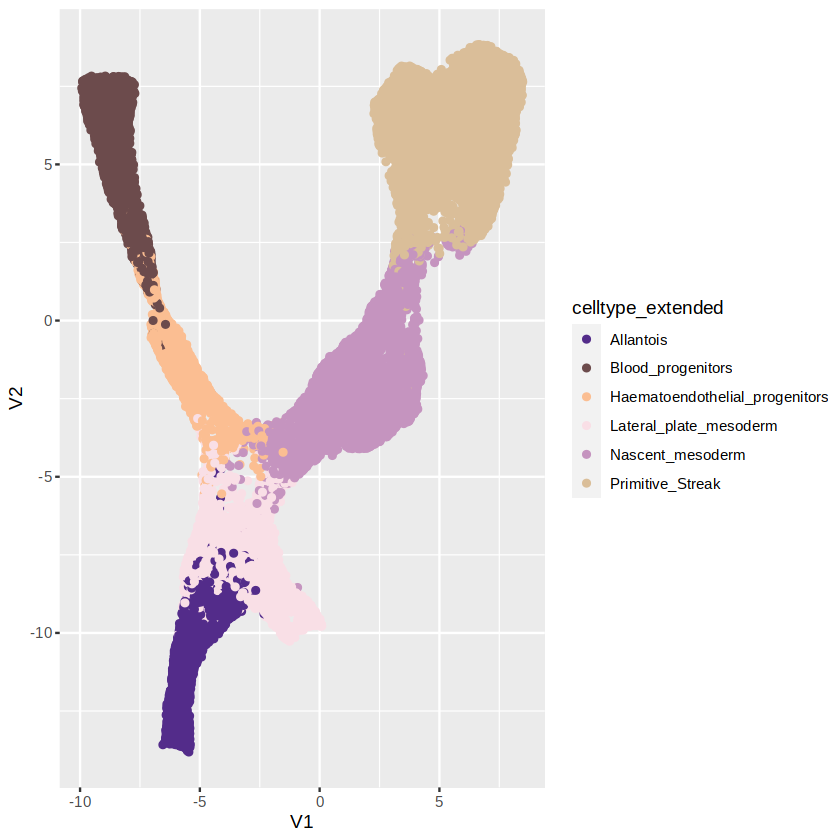

In [48]:
# Fetch UMAP coordinates
to.plot <- reducedDim(rna.sce,"UMAP") %>% as.data.table %>% 
    .[,cell:=colnames(rna.sce)] %>%
    merge(meta, by="cell")

ggplot(to.plot, aes(V1, V2, color = celltype_extended)) + 
    geom_point() + 
    scale_color_manual(values = opts$celltype_extended.colors)

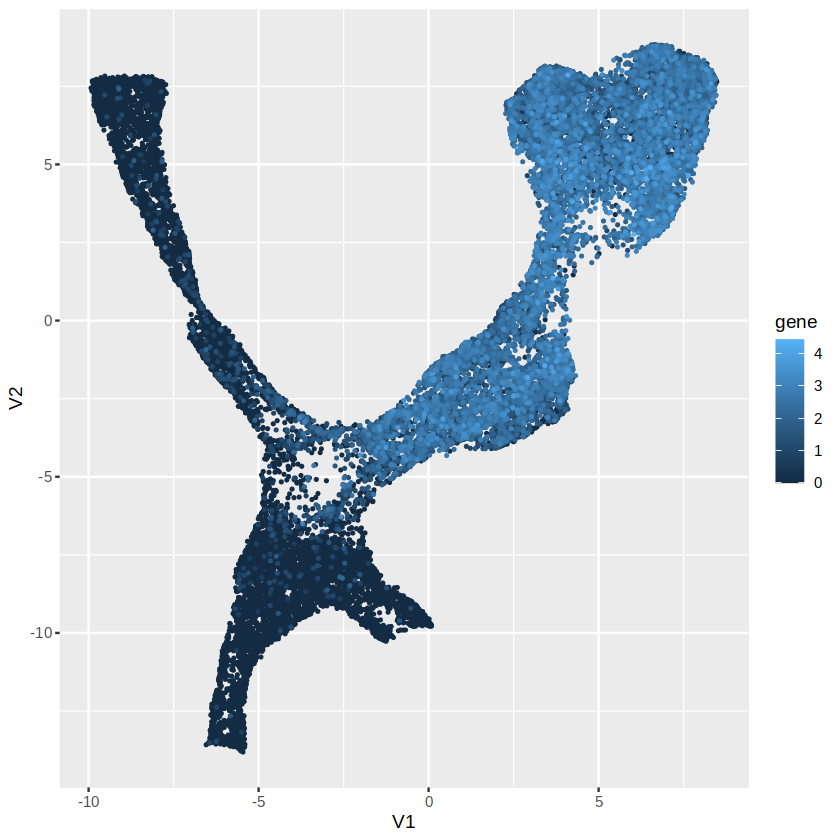

In [49]:
to.plot$gene = as.numeric(logcounts(rna.sce['Eomes',to.plot$cell]))
to.plot2 = to.plot %>% .[order(gene)]
ggplot(to.plot2, aes(V1, V2, color = gene)) + 
    geom_point(size = 0.4)

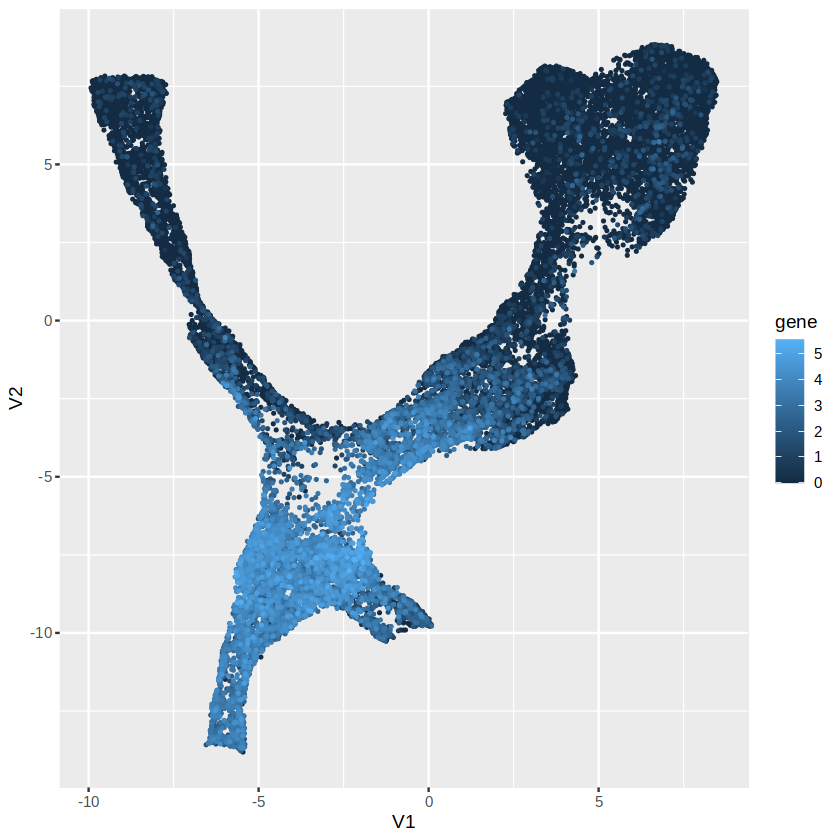

In [50]:
to.plot$gene = as.numeric(logcounts(rna.sce['Hand1',to.plot$cell]))
to.plot2 = to.plot %>% .[order(gene)]
ggplot(to.plot2, aes(V1, V2, color = gene)) + 
    geom_point(size = 0.4)

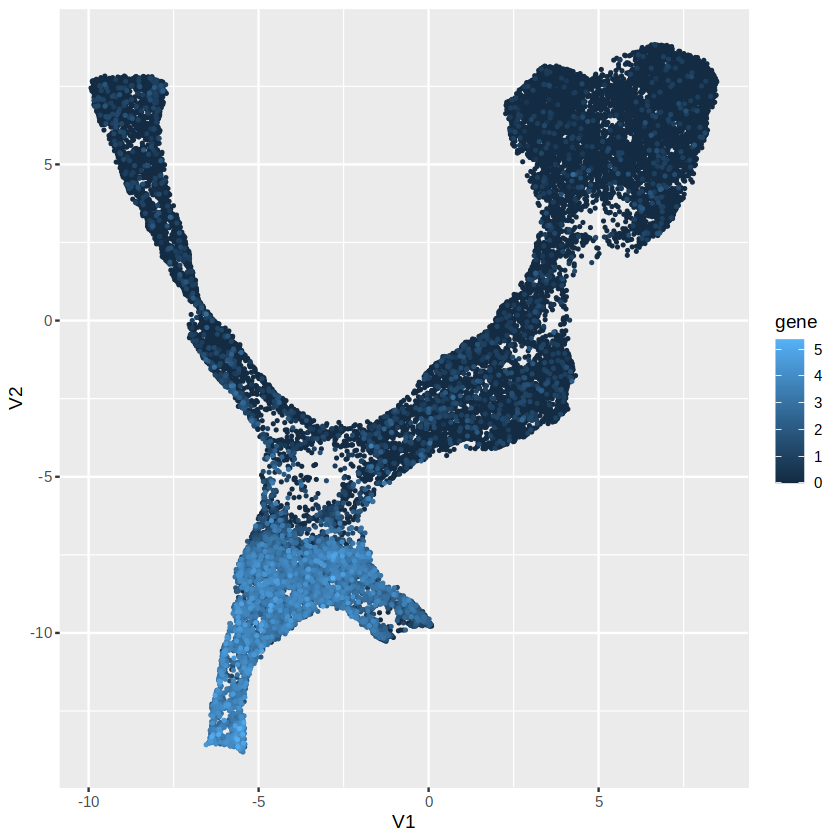

In [51]:
to.plot$gene = as.numeric(logcounts(rna.sce['Dlk1',to.plot$cell]))
to.plot2 = to.plot %>% .[order(gene)]
ggplot(to.plot2, aes(V1, V2, color = gene)) + 
    geom_point(size = 0.4)

In [52]:
library(destiny)

In [53]:
DiffusionMap <- DiffusionMap(reducedDim(rna.sce,"PCA"))

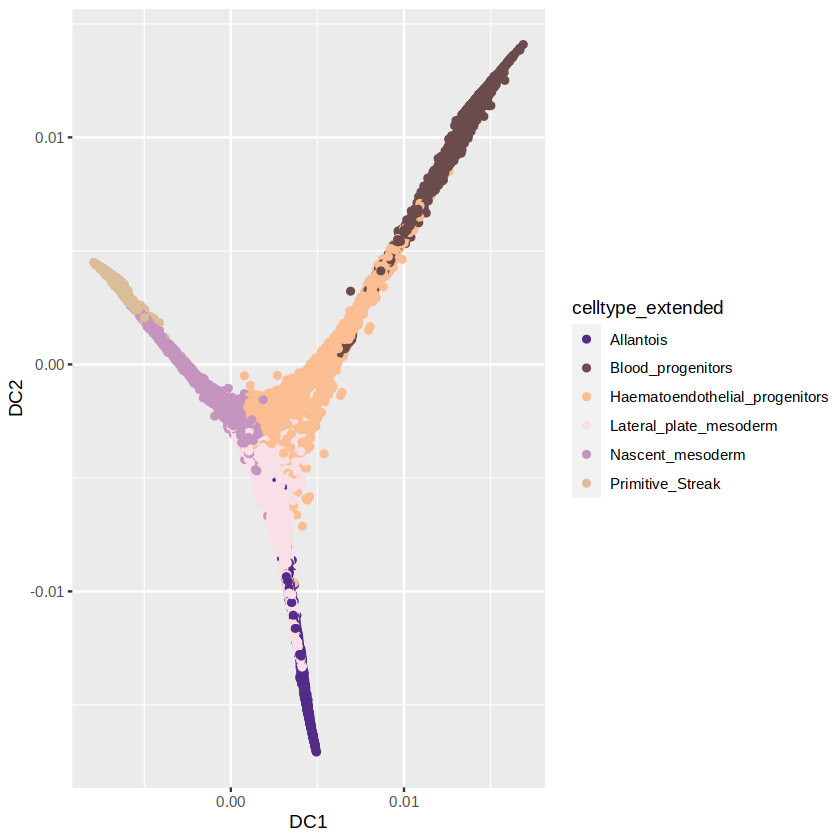

In [54]:
# Fetch UMAP coordinates
to.plot <- DiffusionMap@eigenvectors %>% as.data.table(., keep.rownames = T) %>% setnames('rn', 'cell') %>% 
    .[,cell:=colnames(rna.sce)] %>%
    merge(meta, by="cell")

ggplot(to.plot, aes(DC1, DC2, color = celltype_extended)) + 
    geom_point() + 
    scale_color_manual(values = opts$celltype_extended.colors)

In [55]:
DiffusionMap <- DiffusionMap(reducedDim(rna.sce,"PCA_corrected"))

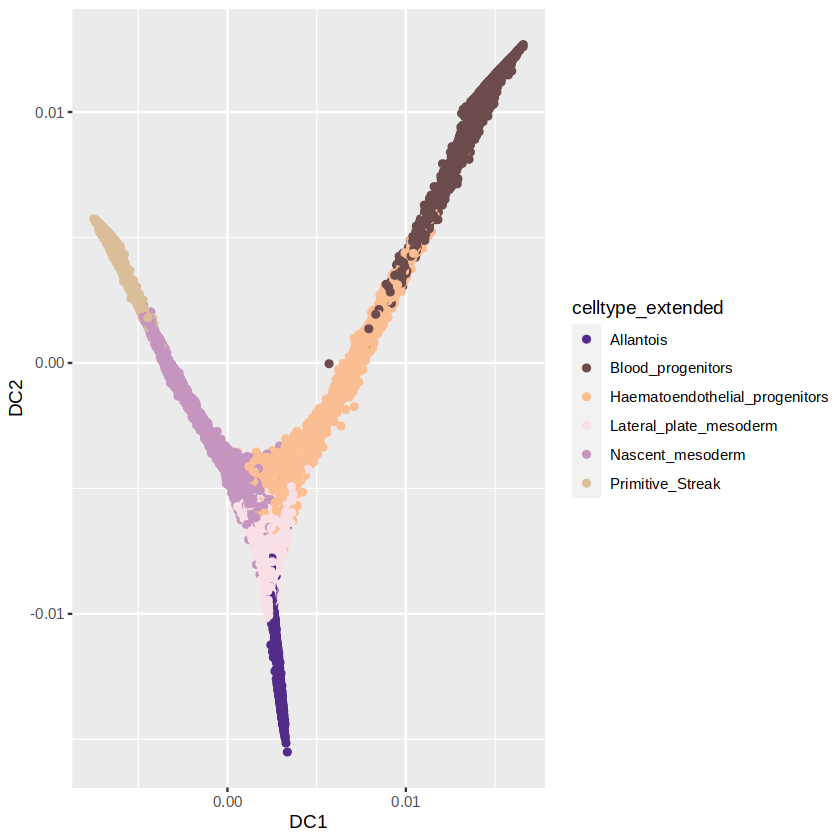

In [56]:
# Fetch UMAP coordinates
to.plot <- DiffusionMap@eigenvectors %>% as.data.table(., keep.rownames = T) %>% setnames('rn', 'cell') %>% 
    .[,cell:=colnames(rna.sce)] %>%
    merge(meta, by="cell")

ggplot(to.plot, aes(DC1, DC2, color = celltype_extended)) + 
    geom_point() + 
    scale_color_manual(values = opts$celltype_extended.colors)

# This seems to work!

In [ ]:
# original run: PCA on 5 dimensions + batch correction, only using first 4 here
# Because of slingshot fuckup

In [57]:
library(slingshot)

In [80]:
rna.sce <- rna.sce_full[,meta$cell]
colData(rna.sce) = meta %>% as.data.frame() %>% tibble::column_to_rownames('cell') %>% DataFrame()
reducedDim(rna.sce, "diffusion") <- DiffusionMap@eigenvectors[,c(1:2)]

In [82]:
set.seed(42)
# Somehow it crashes if I use more than 4 PCs.....
reducedDim(rna.sce, "PCA_corrected") <- pca_atlas_corrected[,c(1:4)] 
rna.sce <- slingshot(rna.sce, 
                     clusterLabels = 'celltype_extended', 
                     start.clus = 'Primitive_Streak', 
                     omega = T,
                     shrink = T,
                     reducedDim='PCA_corrected')

In [86]:
rna.sce$slingshot

class: PseudotimeOrdering 
dim: 23754 2 
metadata(4): lineages mst slingParams curves
pathStats(2): pseudotime weights
cellnames(23754): cell_2 cell_17 ... cell_139282 cell_139316
cellData names(2): reducedDim clusterLabels
pathnames(2): Lineage1 Lineage2
pathData names(0):

In [87]:
reducedDim(rna.sce, "diffusion") <- DiffusionMap@eigenvectors[,c(1:2)]

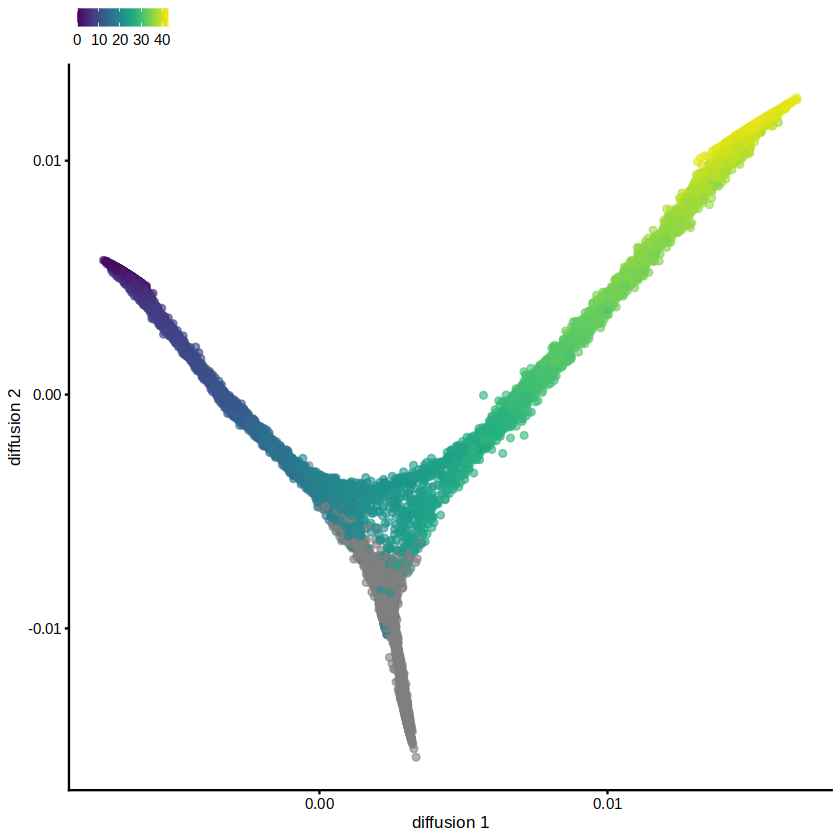

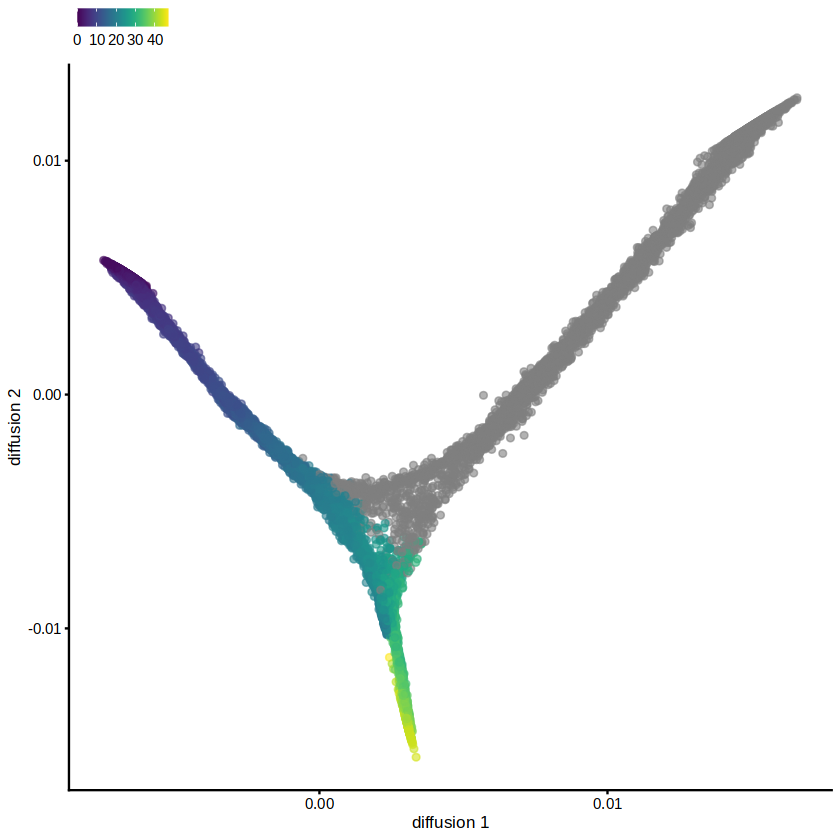

In [88]:
colData(rna.sce)$pseudotime = colData(rna.sce)$slingPseudotime_1 # meta %>% tibble::column_to_rownames("cell") %>% DataFrame
plotReducedDim(rna.sce, dimred = "diffusion", colour_by="pseudotime", ncomponents = c(1,2)) +
    theme(legend.position="top", legend.title = element_blank())

colData(rna.sce)$pseudotime = colData(rna.sce)$slingPseudotime_2 # meta %>% tibble::column_to_rownames("cell") %>% DataFrame
plotReducedDim(rna.sce, dimred = "diffusion", colour_by="pseudotime", ncomponents = c(1,2)) +
    theme(legend.position="top", legend.title = element_blank())

In [77]:
library(tradeSeq)

In [45]:
decomp <- modelGeneVar(rna.sce, block = rna.sce$stage)
decomp <- decomp[decomp$mean > 0.001, ]
decomp$FDR <- p.adjust(decomp$p.value, method = "fdr")
genes = as.data.table(decomp, keep.rownames = T) %>%
    .[order(FDR)] %>% head(5000) %>% .$rn

length(genes)

Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”


[1] 5000

In [47]:
BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 1

U <- model.matrix(~rna.sce$stage + as.factor(rna.sce$sample))
sceGAM <- fitGAM(counts = counts(rna.sce), 
                 sds = rna.sce$slingshot,
                 #U = U, # Don't use replicates for test
                 nknots=8, 
                 genes = genes, # Only look at top 10k genes --> should probably reduce this further since it's already a ton, would improve FDR 
                 parallel = T,
                 BPPARAM=BPPARAM,
                 verbose=T)

Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 5.2 GiB”


  |======================================================================| 100%



In [49]:
saveRDS(sceGAM, file.path(args$outdir, 'sceGAM_v1.rds'))

In [62]:
sceGAM = readRDS(file.path(args$outdir, 'sceGAM_v1.rds'))

In [27]:
# Only run this code if not ran at the beginning:

# Get gene metadata
gene_metadata <- fread(io$gene_metadata) %>% .[,c("chr","ens_id","symbol")] %>%
  .[symbol!="" & ens_id %in% rownames(sceGAM)] %>%
  .[!duplicated(symbol)]

sceGAM = sceGAM[gene_metadata$ens_id,] # keep only genes with gene names

rownames(sceGAM) = gene_metadata[match(rownames(sceGAM), ens_id), symbol] # change rownames to gene names

In [28]:
summary(is.na(rownames(sceGAM)))

   Mode   FALSE 
logical    4919 

In [29]:
library(tradeSeq)

In [30]:
patternRes <- patternTest(sceGAM, l2fc=1) # Perform pattern testing with set l2fc
patternGenes = patternRes %>% as.data.table(keep.rownames=T) %>%
    setnames('rn', 'gene') %>% # rename gene column
    .[waldStat != 0] %>% # Before multiple testing comparison, remove genes that do not qualify according to l2fc
    .[,padj:= p.adjust(pvalue, "fdr")] %>% # Multiple testing comparison
    .[,sig:=ifelse(padj<=0.05, TRUE, FALSE)] # Set significance
nrow(patternGenes[sig==TRUE])

[1] 1398

In [31]:
endRes <- diffEndTest(sceGAM, l2fc=1) # Perform pattern testing with set l2fc
endGenes = endRes %>% as.data.table(keep.rownames=T) %>%
    setnames('rn', 'gene') %>% # rename gene column
    .[waldStat != 0] %>% # Before multiple testing comparison, remove genes that do not qualify according to l2fc
    .[,padj:= p.adjust(pvalue, "fdr")] %>% # Multiple testing comparison
    .[,sig:=ifelse(padj<=0.05, TRUE, FALSE)] # Set significance
nrow(endGenes[sig==TRUE])

[1] 1212

In [32]:
fwrite(patternGenes, file.path(args$outdir, 'patternGenes.txt.gz'))
fwrite(endGenes, file.path(args$outdir, 'endGenes.txt.gz'))

In [33]:
patternGenes = fread(file.path(args$outdir, 'patternGenes.txt.gz'))
endGenes = fread(file.path(args$outdir, 'endGenes.txt.gz'))

In [34]:
genes_keep = unique(rbind(patternGenes[,c('gene', 'waldStat', 'padj', 'sig')], endGenes[,c('gene', 'waldStat', 'padj', 'sig')])[sig==TRUE][order(padj, -waldStat)]$gene)

In [35]:
length(genes_keep)

[1] 1597

In [36]:
head(patternGenes[order(padj)])

gene,waldStat,df,pvalue,fcMedian,padj,sig
<chr>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<lgl>
Crispld1,136.3624,8,0,1.20855460,0,TRUE
Col9a1,305.9125,8,0,1.96784265,0,TRUE
Cfc1,601.4325,8,0,0.59675090,0,TRUE
Fhl2,560.0148,9,0,0.89843695,0,TRUE
Hspd1,142.7817,9,0,0.07476116,0,TRUE
Hspe1,253.7199,9,0,0.02827431,0,TRUE


In [7]:
genes_keep = unique(rbind(patternGenes[,c('gene', 'waldStat', 'padj', 'sig')], endGenes[,c('gene', 'waldStat', 'padj', 'sig')])[sig==TRUE][order(padj, -waldStat)]$gene)

In [40]:
suppressPackageStartupMessages(library(circlize))
suppressPackageStartupMessages(library(scales))
suppressPackageStartupMessages(library(ComplexHeatmap))

# Get smoothed expession
yhatSmooth <- predictSmooth(sceGAM, gene = genes_keep, nPoints = 100, tidy = FALSE)

# minmax normalisation 
minmax = function(x){(x-min(x))/(max(x)-min(x))}
yhatSmooth_minmax = t(apply(yhatSmooth, 1, minmax)) 

# Separate YS and Allantois trajectories
YS = yhatSmooth_minmax[, grepl('lineage1', colnames(yhatSmooth_minmax))] # again trajectory names are switched
Alnt = yhatSmooth_minmax[, grepl('lineage2', colnames(yhatSmooth_minmax))]

In [44]:
set.seed(42)
k = 10
group = kmeans(yhatSmooth_minmax, centers = k)$cluster

row_clust = cluster_within_group(t(yhatSmooth_minmax), group)

In [47]:
# Specify which rows to annotate
rows_to_annotate <- c('Eomes', 'Lhx1', 'Nfatc1', 'Etv2', 'Sox7', 'Tal1',
          'Snai2', 'Hand1', 'Hoxa10',  'Smad3','Sox6', 'Tbx4'
                     )
row_indices <- which(rownames(YS) %in% rows_to_annotate)
row_anno = rowAnnotation(link = anno_mark(at = row_indices, 
        labels = rownames(YS)[row_indices], 
        labels_gp = gpar(fontsize = 10), padding = unit(1, "mm")))

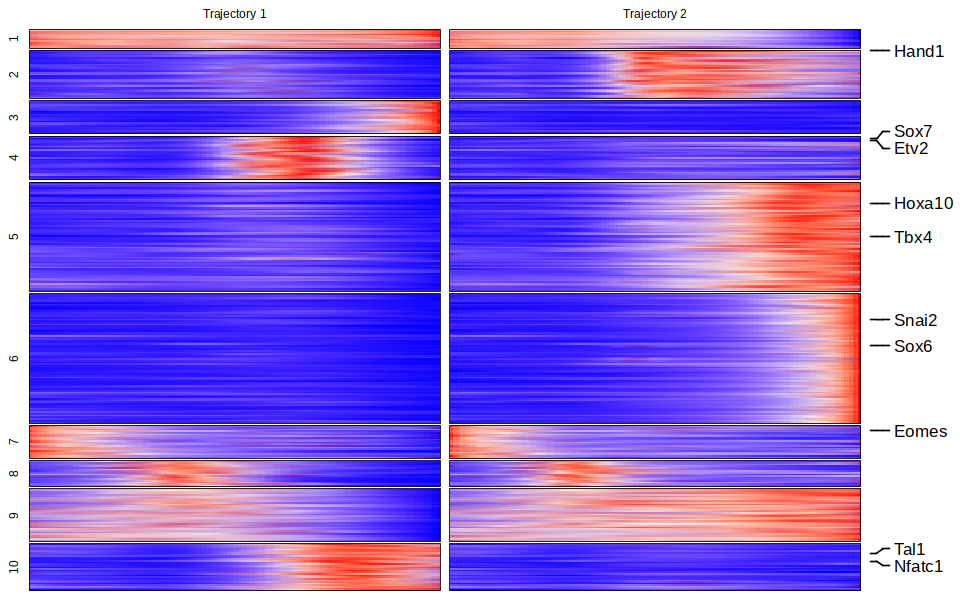

In [48]:
# Clustering
hm_list = Heatmap(Alnt, 
           row_gap = unit(0.5, "mm"),
            cluster_columns = FALSE,
            column_title = 'Trajectory 1',
            show_column_names  = FALSE,
            show_row_names  = FALSE,
          # col = cols,
            show_heatmap_legend = FALSE,
            row_split = group, 
           # left_annotation = ha_row,
            show_row_dend = FALSE,
            row_order = order(group, decreasing = TRUE),
            # heatmap_legend_param = list(title = 'Expression'), 
            row_title_gp = gpar(fontsize = 7),
            column_title_gp = gpar(fontsize = 7),
           # top_annotation = ha_alnt,
            border = TRUE,
            border_gp = gpar(col = "black", lwd = 0.5),
            use_raster = TRUE,
            raster_device = "png",
            raster_quality = 1) + 
          Heatmap(YS, 
           row_gap = unit(0.5, "mm"),
            cluster_columns = FALSE,
            column_title = 'Trajectory 2',
            show_column_names  = FALSE,
            show_row_names  = FALSE,
          #  col = cols,
            show_heatmap_legend = FALSE,
            row_split = group, 
            left_annotation = NULL,
            show_row_dend = FALSE,
            row_order = order(group, decreasing = TRUE),
            column_title_gp = gpar(fontsize = 7),
          #  top_annotation = ha_ys,
            border = TRUE,
            border_gp = gpar(col = "black", lwd = 0.5),
            use_raster = TRUE,
            raster_device = "png",
            raster_quality = 1
                 )

options(repr.plot.height=5, repr.plot.width=8)
plot = draw(hm_list + row_anno)

plot

In [73]:
genes = c('Eomes', 'Lhx1', 'Nfatc1', 'Etv2', 'Sox7', 'Tal1',
          'Snai2', 'Hand1', 'Hoxa10', 'Sox6', 'Tbx4'
         )
yhatSmooth <- predictSmooth(sceGAM, gene = genes, nPoints = 100, tidy=TRUE)

    RNA_filt.dt = as.data.table(yhatSmooth[yhatSmooth$gene %in% genes,]) %>% 
            setnames(c('lineage', 'time', 'yhat'), c('Traj', 'pseudotime', 'Expr')) %>%
            .[,gene:=factor(gene, levels = genes)] %>%
            .[,Traj:=as.character(Traj)]

    p = ggplot(RNA_filt.dt, aes(pseudotime, Expr, color=Traj)) + 
        #    geom_point(size=0.2, alpha=0.2) +
            geom_line(linewidth = 1.3) + 
            scale_color_manual(values=c('2'='chartreuse4', '1'='darkorchid4'), name='Trajectory') + 
            scale_x_continuous(expand=c(0.01,0, 0, 0), breaks=c(seq(2, 50, 3))) + 
            scale_y_continuous(expand=c(0,0, 0.1, 0), breaks=seq(0, 1e3, 3)) + 
        #    geom_smooth(se = F) +
            geom_hline(yintercept=0) +
            facet_wrap(~gene, ncol=12, scales='free_y') + 
            theme_bw() + 
            theme(strip.background = element_blank(),
                  text = element_text(size=20),
                  axis.text = element_text(color='black'),
                  axis.text.x = element_text(angle=-45, hjust=0, vjust=1),
                  axis.text.y = element_blank())

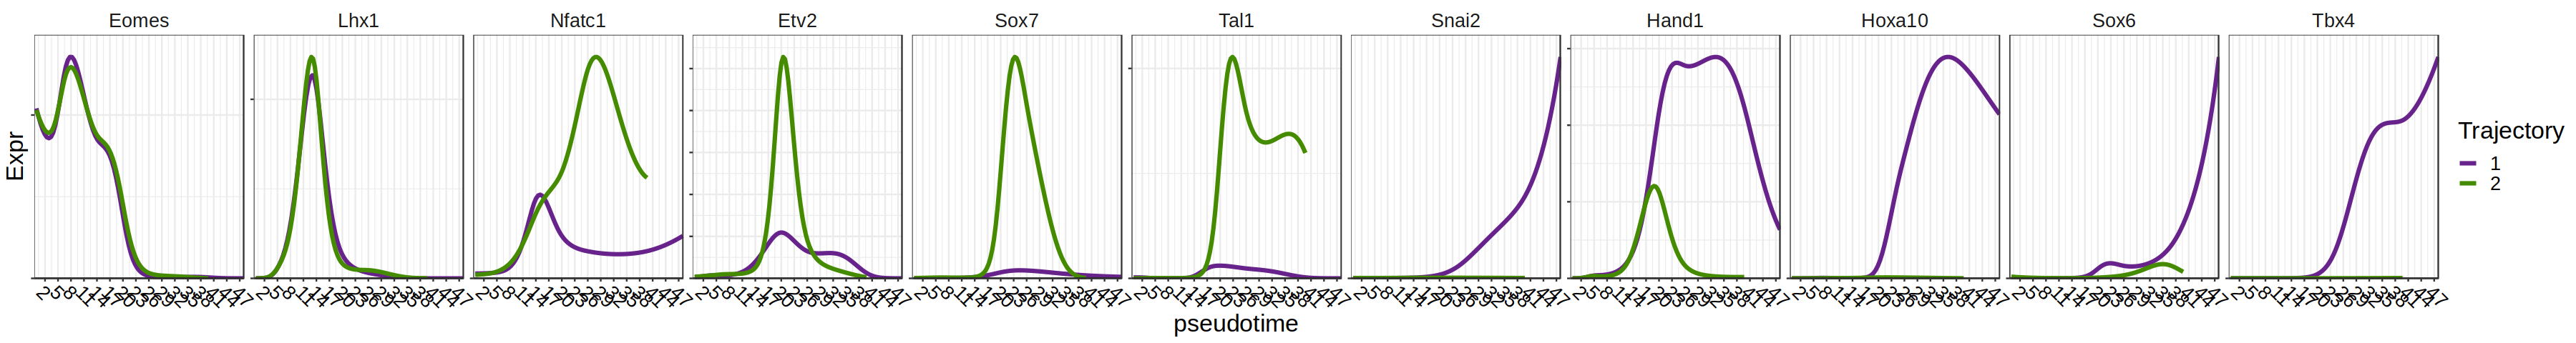

In [74]:
options(repr.plot.height=4, repr.plot.width=30)
p

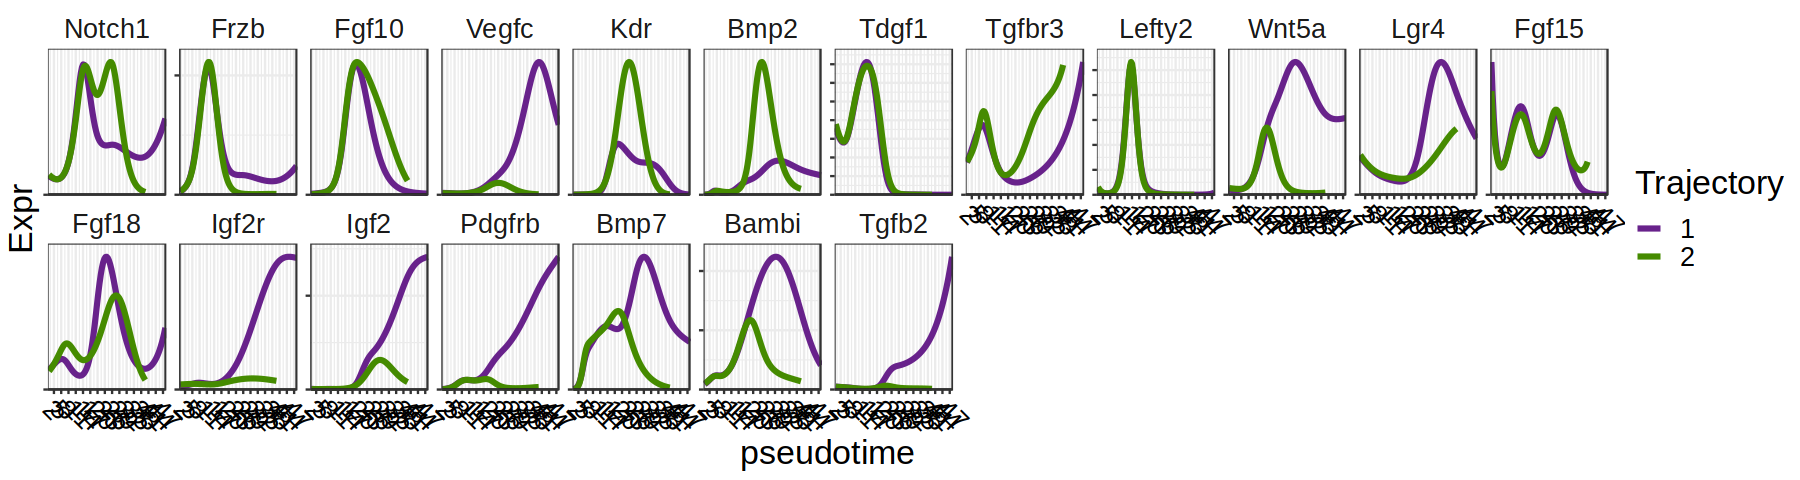

In [76]:
genes = c(
'Notch1','Fzd7',  'Frzb', 'Fgf10','Vegfc', 'Kdr','Bmp2','Tdgf1', 'Tgfbr3','Lefty2',
'Notch3', 'Wnt5a','Lgr4', 'Fgf15', 'Fgf18', 'Igf2r', 'Igf2', 'Pdgfrb', 'Bmp7', 'Bambi', 'Tgfb2', 'Smad9')
genes = genes[genes %in% rownames(sceGAM)]
yhatSmooth <- predictSmooth(sceGAM, gene = genes, nPoints = 100, tidy=TRUE)

    RNA_filt.dt = as.data.table(yhatSmooth[yhatSmooth$gene %in% genes,]) %>% 
            setnames(c('lineage', 'time', 'yhat'), c('Traj', 'pseudotime', 'Expr')) %>%
            .[,gene:=factor(gene, levels = genes)] %>%
            .[,Traj:=as.character(Traj)]

    p = ggplot(RNA_filt.dt, aes(pseudotime, Expr, color=Traj)) + 
        #    geom_point(size=0.2, alpha=0.2) +
            geom_line(linewidth = 1.3) + 
            scale_color_manual(values=c('2'='chartreuse4', '1'='darkorchid4'), name='Trajectory') + 
            scale_x_continuous(expand=c(0.01,0, 0, 0), breaks=c(seq(2, 50, 3))) + 
            scale_y_continuous(expand=c(0,0, 0.1, 0), breaks=seq(0, 1e3, 3)) + 
        #    geom_smooth(se = F) +
            geom_hline(yintercept=0) +
            facet_wrap(~gene, ncol=12, scales='free_y') + 
            theme_bw() + 
            theme(strip.background = element_blank(),
                  text = element_text(size=20),
                  axis.text = element_text(color='black'),
                  axis.text.x = element_text(angle=-45, hjust=0, vjust=1),
                  axis.text.y = element_blank())

options(repr.plot.height=4, repr.plot.width=15)
p

In [65]:
genes = c('Isl1')
genes = genes[genes %in% rownames(sceGAM)]
yhatSmooth <- predictSmooth(sceGAM, gene = genes, nPoints = 100, tidy=TRUE)

    RNA_filt.dt = as.data.table(yhatSmooth[yhatSmooth$gene %in% genes,]) %>% 
            setnames(c('lineage', 'time', 'yhat'), c('Traj', 'pseudotime', 'Expr')) %>%
            .[,gene:=factor(gene, levels = genes)] %>%
            .[,Traj:=as.character(Traj)]

    p = ggplot(RNA_filt.dt, aes(pseudotime, Expr, color=Traj)) + 
        #    geom_point(size=0.2, alpha=0.2) +
            geom_line(linewidth = 1.3) + 
            scale_color_manual(values=c('2'='chartreuse4', '1'='darkorchid4'), name='Trajectory') + 
            scale_x_continuous(expand=c(0.01,0, 0, 0), breaks=c(seq(2, 50, 3))) + 
            scale_y_continuous(expand=c(0,0, 0.1, 0), breaks=seq(0, 1e3, 3)) + 
        #    geom_smooth(se = F) +
            geom_hline(yintercept=0) +
            facet_wrap(~gene, ncol=12, scales='free_y') + 
            theme_bw() + 
            theme(strip.background = element_blank(),
                  text = element_text(size=20),
                  axis.text = element_text(color='black'),
                  axis.text.x = element_text(angle=-45, hjust=0, vjust=1),
                  axis.text.y = element_blank())

options(repr.plot.height=4, repr.plot.width=4)
p

ERROR: Error in beta[as.character(gene[jj]), , drop = FALSE]: subscript out of bounds
